## Your Quantum Lucky Number
### A perfect random number generator based on the laws of quantum mechanics
According to the laws of quantum mechanics, when you prepare a two-state system (a qubit here) to be in a (Bell) superposition of the two pure states and subsequently perform a measurement on it, its state will collapse to either of the pure states with equal probability. Hence the result of such a measurement can be cast as a binary random variable (0 or 1) with equal (50-50) probabilities. Here we assume that if we repeat the prepare-measure process 8 times (8 shots) we end up with an 8-digit binary number: your quantum lucky number.
This could have more scientific applications, as it can replace pseudo-random number generators with a perfectly random number generator.


In [1]:
#Requirements
#pip install qiskit pylatexenc qiskit-aer qiskit-ibm-runtime
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister


#### Design the device (circuit in QC jargon) that would generate your lucky number

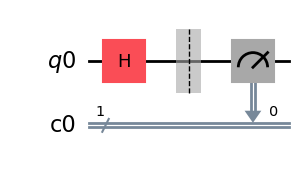

In [2]:
# Number of qubits utilised simultaneously.
glo_num_qubits = 1

def create_circuit(num_target_qubits: int) -> QuantumCircuit:
    """
    Creates and returns quantum circuit for random variate generation.
    :param num_target_qubits: number of qubits to be used.
    :return: quantum curcuit.
    """
    assert isinstance(num_target_qubits, int) and num_target_qubits > 0
    q = QuantumRegister(num_target_qubits)
    c = ClassicalRegister(num_target_qubits)
    circuit = QuantumCircuit(q, c)
    circuit.h(q)
    circuit.barrier()
    circuit.measure(q, c)
    return circuit

# Create and plot generating quantum circuit.
circuit = create_circuit(glo_num_qubits)
#print(circuit)
circuit.draw(output='mpl')

#### First try it on a simulator (simulates QC on a not-QC)
##### Not necessary, but, my boss says I should have a unit test for every line of code I write

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
# Use AerSimulator instead of BasicAer
backendC = AerSimulator()
# Transpile and run the circuit
transpiled_circuit = transpile(circuit, backendC)
job = backendC.run(transpiled_circuit, shots=8, memory=True)
result = job.result()
counts = result.get_counts()
print(counts)
bit_str = ''.join(job.result().get_memory())
print("Your classical-lucky number is:", int(bit_str,2))

{'0': 8}
Your classical-lucky number is: 0


#### Next do it on the real QC (IBMQ) 
##### You can obtain a free token after you register at IBMQ site

In [4]:
my_ibmq_token = ""
#Prompting user for IBM Quantum token
my_ibmq_token = input('Enter your IBM Quantum token: ')

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=my_ibmq_token, overwrite=True)
service = QiskitRuntimeService()

backendq = service.least_busy(simulator=False, operational=True)
transpiled_circuit = transpile(circuit, backendq)


qiskit_runtime_service.__init__:WARNING:2026-04-01 13:41:44,012: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-01 13:41:44,319: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-01 13:41:46,194: Using instance: open-instance, plan: open


In [6]:

from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler = Sampler(mode=backendq)
job = sampler.run([transpiled_circuit], shots=8) # Pass a list of PUBs
result = job.result()

# Accessing counts (assuming classical register is named 'meas')
pub_result = result[0]


In [7]:
bit_str = ''.join(pub_result.data.c0.get_bitstrings())
print("Your quantum-lucky number is:", int(bit_str,2))

Your quantum-lucky number is: 230


In [8]:
print(pub_result.data.keys())
print([reg.name for reg in circuit.cregs])

dict_keys(['c0'])
['c0']


In [9]:
#counts = pub_result.data.c0.get_counts()
#print(counts)
##{'0': 5, '1': 3}
#pub_result.data.c0.get_bitstrings()
##['0', '1', '0', '1', '0', '1', '0', '0']
#bit_str = ''.join(pub_result.data.c0.get_bitstrings())
#int(bit_str,2)
## 84